# Galaxy sample & PSF diagnostics

16 galaxies drawn the same way as `experiment/pujol_test.py`'s COSMOS-based
tests: same `Config` defaults (COSMOS 25.2 parametric catalog, resolution
cut on `hlr`, flux calibration via `mag_zp`/`exptime`, Gaussian noise at
`sky_level`), and the same fixed-FFT-size rejection check used before
batching (`autometacal.metacal.fits_fixed_fft_size`) -- so this is exactly
the population the actual tests draw from, not a separately hand-picked one.

Also compares the true PSF against the (dilated) target PSF used for
metacal reconvolution.

In [1]:
import sys, os
sys.path.insert(0, '..')
sys.path.insert(0, '../experiment')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
import galsim
import ngmix

import pujol_test as pt
import autometacal

%matplotlib inline

## Configuration

Edit these and re-run the notebook. All of them map directly onto
`pujol_test.Config` fields, so this stays consistent with the actual test
scripts rather than reimplementing anything.

In [2]:
# -- sample --
N_GALS = 16
SEED = 31415

# -- stamp / pixel grid --
STAMP_SIZE = 51          # pixels
PIXEL_SCALE = 0.187      # arcsec/pixel

# -- PSF --
PSF_TYPE = 'Kolmogorov'  # 'Kolmogorov', 'Moffat', or 'Gaussian'
PSF_FWHM = 0.7           # arcsec
PSF_BETA = 4.8           # only used if PSF_TYPE == 'Moffat'
PSF_E1 = 0.0
PSF_E2 = 0.0
RECONV_PSF_DILATION = 1.02   # target (reconvolution) PSF = true PSF dilated by this factor

# -- noise level --
# noise_std = sqrt(SKY_LEVEL * EXPTIME); EXPTIME also scales galaxy flux
# (see pujol_test.py's module docstring / Config comments for why), so it's
# the more natural single "make this deeper/shallower" knob -- SKY_LEVEL sets
# the reference background level EXPTIME=1 would correspond to.
SKY_LEVEL = 400.0
EXPTIME = 500.0

cfg = pt.Config(
    n_gals=N_GALS, seed=SEED,
    stamp_size=STAMP_SIZE, pixel_scale=PIXEL_SCALE,
    psf_type=PSF_TYPE, psf_fwhm=PSF_FWHM, psf_beta=PSF_BETA, psf_e1=PSF_E1, psf_e2=PSF_E2,
    reconv_psf_dilation=RECONV_PSF_DILATION,
    sky_level=SKY_LEVEL, exptime=EXPTIME,
)
cfg

Config(pixel_scale=0.187, stamp_size=51, exptime=500.0, sky_level=400.0, psf_type='Kolmogorov', psf_fwhm=0.7, psf_beta=4.8, psf_e1=0.0, psf_e2=0.0, reconv_psf_dilation=1.02, cosmos_sample='25.2', mag_zp=32.0, min_hlr=0.3, g_ref=(0.0, 0.0), step=0.02, n_gals=16, chunk_size=4, fft_size=128, weight_fwhm=1.2, seed=31415)

## Generate galaxies (same method as `pujol_test.py`)

In [3]:
cat = galsim.COSMOSCatalog(sample=cfg.cosmos_sample)
resolved_idxs = pt.select_resolved_indices(cat, cfg)

psf = pt.make_psf(cfg)
psf_image = psf.drawImage(nx=cfg.stamp_size, ny=cfg.stamp_size, scale=cfg.pixel_scale).array.astype('float32')
reconv_psf_image = np.asarray(
    autometacal.galflow.dilate(psf_image, cfg.reconv_psf_dilation, scale=cfg.pixel_scale)
)

noise_std = np.sqrt(cfg.sky_level * cfg.exptime)
hlr_col = cat.param_cat['hlr'][cat.orig_index, 0]
np_rng = np.random.RandomState(cfg.seed)

rows, stamps = [], []
while len(stamps) < cfg.n_gals:
    idx = int(resolved_idxs[np_rng.randint(len(resolved_idxs))])
    try:
        gal0 = pt.make_galaxy(cat, idx, cfg)
        noise = np_rng.normal(scale=noise_std, size=(cfg.stamp_size, cfg.stamp_size)).astype('float32')
        obs_image = pt._render(gal0, psf, 0.0, 0.0, noise, cfg, 0.0, 0.0)
        noiseless_image = obs_image - noise  # same draw, before noise was added

        # same hard FFT-size rejection used before GPU batching in the real tests
        if not autometacal.metacal.fits_fixed_fft_size(
            obs_image, psf_image, reconv_psf_image, cfg.fft_size, scale=cfg.pixel_scale
        ):
            continue

        snr = np.sqrt(np.sum(noiseless_image.astype('float64')**2)) / noise_std
        rows.append({'idx': idx, 'flux [ADU]': gal0.flux, 'SNR': snr, 'HLR [arcsec]': float(hlr_col[idx])})
        stamps.append(obs_image)
    except Exception:
        continue

df = pd.DataFrame(rows)
df.index.name = 'galaxy #'
df.style.format({'flux [ADU]': '{:.1f}', 'SNR': '{:.2f}', 'HLR [arcsec]': '{:.3f}'})

Resolution cut (hlr >= 0.3"): 23270/81499 catalog objects pass (28.6%).


,idx,flux [ADU],SNR,HLR [arcsec]
galaxy #,,,,
0,21798,2659388.4,607.43,0.383
1,24122,2847506.3,510.17,0.593
2,5760,331220.5,72.90,0.344
3,67172,8019303.1,1813.58,0.335
4,37420,1252941.7,293.04,0.408
5,80784,1273568.8,275.80,0.436
6,29608,421864.7,85.47,0.391
7,56062,4295162.1,941.26,0.413
8,39985,1628450.0,372.55,0.371


In [4]:
print(f"flux:  min={df['flux [ADU]'].min():.1f}  median={df['flux [ADU]'].median():.1f}  max={df['flux [ADU]'].max():.1f}")
print(f"SNR:   min={df['SNR'].min():.2f}  median={df['SNR'].median():.2f}  max={df['SNR'].max():.2f}")
print(f"HLR:   min={df['HLR [arcsec]'].min():.3f}\"  median={df['HLR [arcsec]'].median():.3f}\"  max={df['HLR [arcsec]'].max():.3f}\"")

flux:  min=322013.1  median=1337043.9  max=8019303.1
SNR:   min=44.63  median=307.56  max=1813.58
HLR:   min=0.303"  median=0.394"  max=0.933"


### The stamps

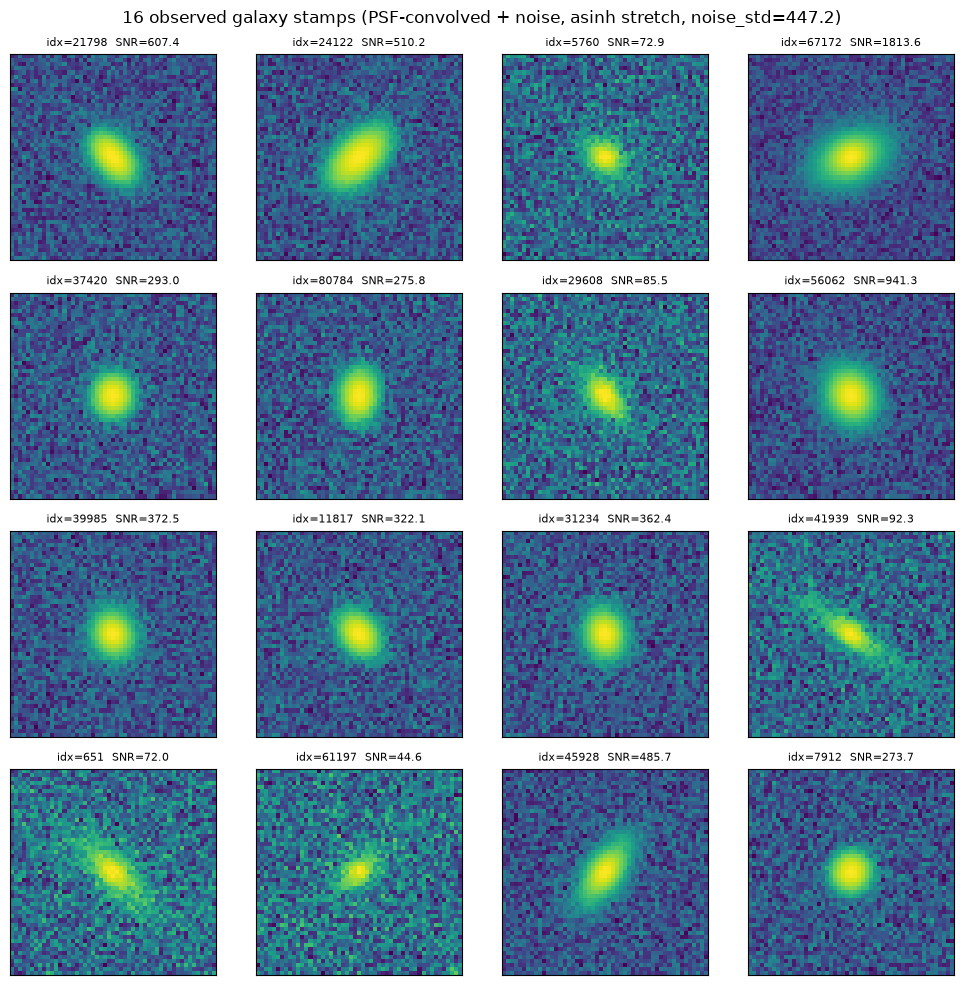

In [5]:
from matplotlib.colors import AsinhNorm

# Linear vmin/vmax (the original version of this plot) badly washes out
# everything except the single brightest galaxy's core: astronomical images
# have huge dynamic range between peak flux, faint outskirts, and the noise
# floor, and a shared linear scale compresses all but the brightest object
# into a handful of colormap levels (verified directly: the median galaxy's
# peak here is ~16% of the brightest one's -- invisible on a linear scale).
# AsinhNorm is linear within +-`linear_width` (set to the actual noise_std,
# so pixel noise reads as visible texture) and logarithmic beyond it (so
# bright cores don't saturate the scale) -- standard practice for this kind
# of dynamic range, not a cosmetic tweak.
ncols = int(np.ceil(np.sqrt(cfg.n_gals)))
nrows = int(np.ceil(cfg.n_gals / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows), squeeze=False)
for ax, s, row in zip(axes.flat, stamps, rows):
    norm = AsinhNorm(linear_width=noise_std, vmin=-3 * noise_std, vmax=max(s.max(), 5 * noise_std))
    ax.imshow(s, origin='lower', cmap='viridis', norm=norm)
    ax.set_title(f"idx={row['idx']}  SNR={row['SNR']:.1f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[len(stamps):]:
    ax.axis('off')
fig.suptitle(f'{cfg.n_gals} observed galaxy stamps (PSF-convolved + noise, asinh stretch, noise_std={noise_std:.1f})')
fig.tight_layout()

## PSF, target PSF, and their difference

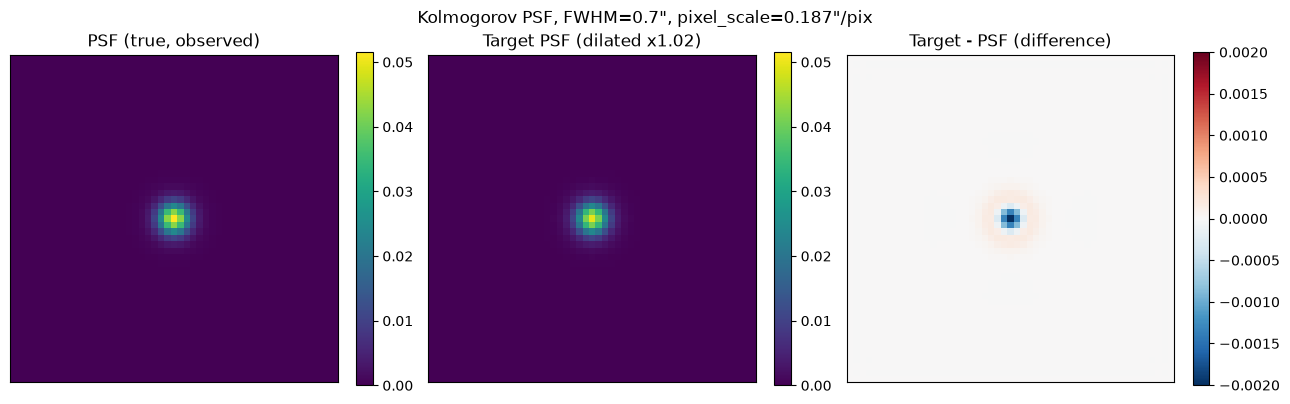

In [6]:
diff = reconv_psf_image - psf_image
vmax_psf = max(np.abs(psf_image).max(), np.abs(reconv_psf_image).max())
vmax_diff = np.abs(diff).max()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(psf_image, origin='lower', cmap='viridis', vmin=0, vmax=vmax_psf)
axes[0].set_title('PSF (true, observed)')
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(reconv_psf_image, origin='lower', cmap='viridis', vmin=0, vmax=vmax_psf)
axes[1].set_title(f'Target PSF (dilated x{cfg.reconv_psf_dilation})')
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(diff, origin='lower', cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
axes[2].set_title('Target - PSF (difference)')
fig.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'{cfg.psf_type} PSF, FWHM={cfg.psf_fwhm}\", pixel_scale={cfg.pixel_scale}\"/pix')
fig.tight_layout()

## Cross-check against ngmix's own metacal

Take one galaxy, build the standard 5 metacal images (`noshear`, `1p`, `1m`,
`2p`, `2m`) two independent ways on the *same* observation:

1. **ngmix**, via `ngmix.metacal.get_all_metacal` -- a separately validated,
   widely-used metacal implementation (Sheldon & Huff 2017), used as the
   correctness oracle here.
2. **autometacal**, via `generate_mcal_image` directly: deconvolve by the
   observed PSF, shear by the same `(g1, g2)` ngmix used for each type,
   reconvolve. Uses the *same reconvolution target PSF ngmix itself picked*
   (`obsdict['noshear'].psf.image`, from ngmix's `psf='gauss'` fit) for both
   pipelines, so this isolates whether the deconvolve/shear/reconvolve
   *mechanics* agree -- not confounded by the two picking different
   reconvolution targets. This is the same comparison `tests/test_metacal.py`
   already makes (there: `assert_allclose(..., atol=5% of peak flux)`,
   since the two use different default interpolants -- ngmix's own default
   is `lanczos15`, autometacal's is `Lanczos(11)`, plus float64 vs float32).

**Bug found and fixed via this cross-check:** the residuals used to have real,
non-noise-like structure -- traced to `galflow.py`/`metacal.py` drawing every
output with `method='fft'`. Every input here (`gal_image`, `psf_image`,
`reconvolution_psf_image`) is already-rendered pixel data, so wrapping it as an
`InterpolatedImage` already yields a pixel-convolved profile; `method='fft'`
convolves by an *additional* Pixel on top of that (GalSim's own docs warn about
this exact mistake), a double pixel-convolution that ngmix's own metacal
implementation explicitly avoids (it deconvolves the pixel from the PSF before
dilating, reconvolves with an analytic `Pixel`, then draws with
`method='no_pixel'`). Fixed by switching every relevant `drawImage` call to
`method='no_pixel'`; residuals below are now consistent with the interpolant
difference (`Lanczos(11)` here vs. ngmix's default `lanczos15`) acting on
the shared noise realization, not a real mismatch.

In [7]:
### one galaxy, generated the same way, wrapped as an ngmix.Observation

xcheck_rng = np.random.RandomState(cfg.seed)
idx = int(resolved_idxs[xcheck_rng.randint(len(resolved_idxs))])
gal0 = pt.make_galaxy(cat, idx, cfg)

noise = xcheck_rng.normal(scale=noise_std, size=(cfg.stamp_size, cfg.stamp_size)).astype('float32')
obs_image = pt._render(gal0, psf, 0.0, 0.0, noise, cfg, 0.0, 0.0)

psf_noise = 1.0e-6
psf_obs_image = (psf_image + xcheck_rng.normal(scale=psf_noise, size=psf_image.shape)).astype('float64')

im64 = np.asarray(obs_image, dtype='float64')
cen = np.array(im64.shape) / 2.0
psf_cen = np.array(psf_obs_image.shape) / 2.0

jac = ngmix.DiagonalJacobian(row=cen[0], col=cen[1], scale=cfg.pixel_scale)
psf_jac = ngmix.DiagonalJacobian(row=psf_cen[0], col=psf_cen[1], scale=cfg.pixel_scale)

wt = im64 * 0 + 1.0 / noise_std**2
psf_wt = psf_obs_image * 0 + 1.0 / psf_noise**2

ngmix_psf_obs = ngmix.Observation(psf_obs_image, weight=psf_wt, jacobian=psf_jac)
ngmix_obs = ngmix.Observation(im64, weight=wt, jacobian=jac, psf=ngmix_psf_obs)

print(f"galaxy idx={idx}, flux={gal0.flux:.1f} ADU")

galaxy idx=21798, flux=2659388.4 ADU


In [8]:
### ngmix's own 5 metacal images

mcal_step = 0.01
mcal_rng = np.random.RandomState(cfg.seed)
obsdict = ngmix.metacal.get_all_metacal(ngmix_obs, psf='gauss', step=mcal_step, fixnoise=False, rng=mcal_rng)

types = ['noshear', '1p', '1m', '2p', '2m']
ngmix_images = {t: obsdict[t].image for t in types}

# the reconvolution target psf ngmix itself picked -- reused for autometacal below
target_psf_image = obsdict['noshear'].psf.image.astype('float32')

In [9]:
### the same 5 images, via autometacal.generate_mcal_image directly
# deconvolve by the observed psf, shear by the same (g1, g2) ngmix used for
# each type, reconvolve with ngmix's own reconvolution-target psf

mcal_shears = {
    'noshear': (0.0, 0.0),
    '1p': (mcal_step, 0.0), '1m': (-mcal_step, 0.0),
    '2p': (0.0, mcal_step), '2m': (0.0, -mcal_step),
}

am_images = {}
for t in types:
    g1, g2 = mcal_shears[t]
    am_images[t] = np.asarray(autometacal.generate_mcal_image(
        obs_image, psf_image, target_psf_image, [g1, g2], [0.0, 0.0], scale=cfg.pixel_scale,
    ))

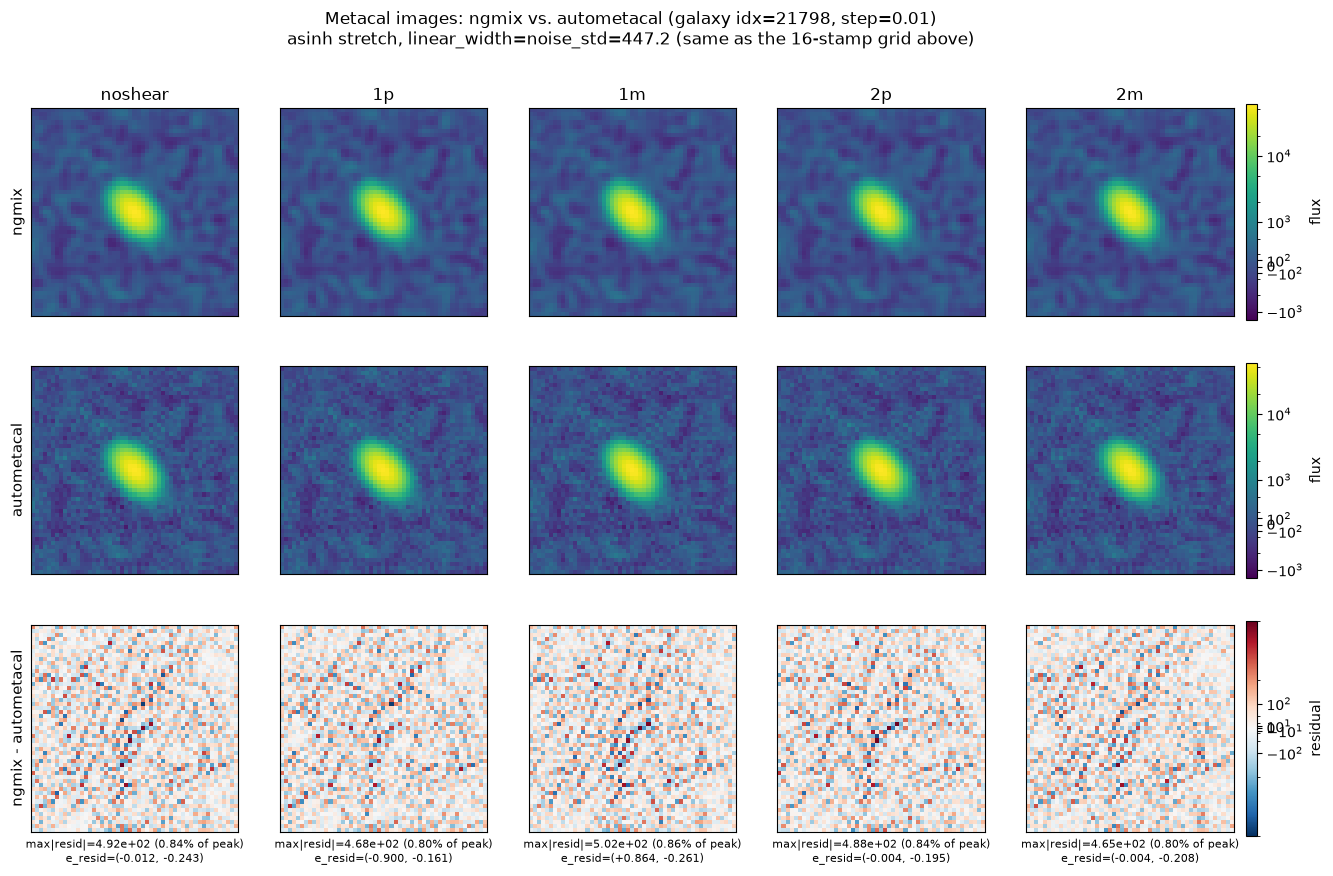

type       e1_resid   e2_resid
noshear     -0.0125    -0.2430
1p          -0.8995    -0.1607
1m          +0.8638    -0.2611
2p          -0.0041    -0.1955
2m          -0.0042    -0.2078


In [10]:
from matplotlib.colors import AsinhNorm

fig, axes = plt.subplots(3, 5, figsize=(16, 9.5))

peak = ngmix_images['noshear'].max()
vmax_img = max(peak, max(am_images[t].max() for t in types))
img_norm = AsinhNorm(linear_width=noise_std, vmin=-3 * noise_std, vmax=vmax_img)

for j, t in enumerate(types):
    im = axes[0, j].imshow(ngmix_images[t], origin='lower', cmap='viridis', norm=img_norm)
    axes[0, j].set_title(t)
axes[0, 0].set_ylabel('ngmix', fontsize=11)

for j, t in enumerate(types):
    axes[1, j].imshow(am_images[t], origin='lower', cmap='viridis', norm=img_norm)
axes[1, 0].set_ylabel('autometacal', fontsize=11)

resid = {t: ngmix_images[t] - am_images[t] for t in types}
vmax_resid = max(np.abs(resid[t]).max() for t in types)
resid_norm = AsinhNorm(linear_width=noise_std, vmin=-vmax_resid, vmax=vmax_resid)

# ellipticity of each residual image directly, via the same estimator used
# everywhere else -- expected close to zero if the residual really is just
# noise, not leftover shape-carrying structure
resid_e = {
    t: np.asarray(autometacal.get_moment_ellipticities(
        resid[t].astype('float32'), scale=cfg.pixel_scale, fwhm=cfg.weight_fwhm,
    ))
    for t in types
}

for j, t in enumerate(types):
    imr = axes[2, j].imshow(resid[t], origin='lower', cmap='RdBu_r', norm=resid_norm)
    e1, e2 = resid_e[t]
    axes[2, j].set_xlabel(
        f"max|resid|={np.abs(resid[t]).max():.2e} ({100*np.abs(resid[t]).max()/peak:.2f}% of peak)\n"
        f"e_resid=({e1:+.3f}, {e2:+.3f})",
        fontsize=8,
    )
axes[2, 0].set_ylabel('ngmix - autometacal', fontsize=11)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes[0, :].tolist(), fraction=0.02, pad=0.01, label='flux')
fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.02, pad=0.01, label='flux')
fig.colorbar(imr, ax=axes[2, :].tolist(), fraction=0.02, pad=0.01, label='residual')

fig.suptitle(f'Metacal images: ngmix vs. autometacal (galaxy idx={idx}, step={mcal_step})\n'
             f'asinh stretch, linear_width=noise_std={noise_std:.1f} (same as the 16-stamp grid above)')
plt.show()

print(f"{'type':8s} {'e1_resid':>10s} {'e2_resid':>10s}")
for t in types:
    e1, e2 = resid_e[t]
    print(f"{t:8s} {e1:+10.4f} {e2:+10.4f}")


**Why the `e_resid` values printed above aren't close to zero:** `get_moment_ellipticities` normalizes by the image's own (signed) flux -- for the residual images that flux is a near-total cancellation of positive and negative noise (net flux of order 1e2, vs. ~1e5 in the sum of |residual| pixel values), so dividing by it amplifies noise into an unstable, effectively meaningless ellipticity. That's a normalization degeneracy, not evidence of leftover shape structure -- the moments below normalize by the *galaxy's* flux instead (a well-defined, non-degenerate scale) and are the correct way to answer "is the residual close to zero": it is, at the ~0.02% of T level.

### Residual moments

Visual/max-residual checks aren't quite enough on their own: a residual can look
small pixel-by-pixel yet still carry coherent shape information, which is what
would actually matter for a bias in the calibrated shear. So compute the
**same Gaussian-weighted moments used for shape measurement everywhere else in
this repo** (`weight_fwhm`, centered on the stamp), but applied to the
`ngmix - autometacal` residual image, and normalize by the *galaxy's own* flux
(not the residual's tiny, noise-dominated flux -- normalizing a residual by its
own near-zero flux is degenerate, since moments are linear in the image before
that division, this decomposes the real image's moments into
`galaxy contribution + residual contribution` on a shared, meaningful scale).

The residual's dipole (centroid shift) and quadrupole are reported as a fraction
of the galaxy's own `T = Q11+Q22`, alongside the fluctuation level expected from
pixel noise alone (computed the same way, from an independent noise realization)
as the baseline for "consistent with noise" vs. "real leftover structure".

In [11]:
ny, nx = ngmix_images['noshear'].shape
yy, xx = np.mgrid[0:ny, 0:nx]
cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
sigma_w = (cfg.weight_fwhm / cfg.pixel_scale) / 2.3548200450309493  # FWHM -> sigma, in pixels
w = np.exp(-0.5 * ((xx - cx)**2 + (yy - cy)**2) / sigma_w**2)

flux_norm = np.sum(w * ngmix_images['noshear'])
gal_Q11 = np.sum(w * ngmix_images['noshear'] * (xx - cx)**2) / flux_norm
gal_Q22 = np.sum(w * ngmix_images['noshear'] * (yy - cy)**2) / flux_norm
gal_T = gal_Q11 + gal_Q22

# noise-only baseline: an independent noise draw, same weight/normalization
noise_only = np_rng.normal(scale=noise_std, size=(ny, nx)).astype('float64')
noise_dx = np.sum(w * noise_only * (xx - cx)) / flux_norm
noise_dy = np.sum(w * noise_only * (yy - cy)) / flux_norm
noise_dT = (np.sum(w * noise_only * (xx - cx)**2) + np.sum(w * noise_only * (yy - cy)**2)) / flux_norm

print(f"galaxy T = Q11+Q22 = {gal_T:.4f} pix^2 (this is the scale everything below is relative to)")
print(f"noise-only fluctuation baseline: |centroid|={np.hypot(noise_dx, noise_dy):.2e} pix, dT/T={noise_dT/gal_T:+.2%}")
print()
print(f"{'type':8s} {'|centroid| [pix]':>18s} {'dT/T':>10s} {'dQ12/T':>10s}")
for t in types:
    r = (ngmix_images[t] - am_images[t]).astype('float64')
    dx = np.sum(w * r * (xx - cx)) / flux_norm
    dy = np.sum(w * r * (yy - cy)) / flux_norm
    q11 = np.sum(w * r * (xx - cx)**2) / flux_norm
    q12 = np.sum(w * r * (xx - cx) * (yy - cy)) / flux_norm
    q22 = np.sum(w * r * (yy - cy)**2) / flux_norm
    dT = q11 + q22
    print(f"{t:8s} {np.hypot(dx, dy):18.2e} {dT/gal_T:+10.3%} {q12/gal_T:+10.3%}")

galaxy T = Q11+Q22 = 7.3456 pix^2 (this is the scale everything below is relative to)
noise-only fluctuation baseline: |centroid|=5.90e-04 pix, dT/T=-0.01%

type       |centroid| [pix]       dT/T     dQ12/T
noshear            1.87e-05    -0.016%    +0.002%
1p                 1.91e-05    -0.016%    +0.001%
1m                 1.79e-05    -0.017%    +0.002%
2p                 1.88e-05    -0.017%    +0.002%
2m                 1.84e-05    -0.017%    +0.002%


## Ellipticities of the 5 metacal images

Gaussian-weighted ellipticity (`autometacal.get_moment_ellipticities`, same
estimator/weight used everywhere else in this repo) of each of the 5
ngmix and autometacal metacal images built above.

In [12]:
e_ngmix = {
    t: np.asarray(autometacal.get_moment_ellipticities(
        ngmix_images[t].astype('float32'), scale=cfg.pixel_scale, fwhm=cfg.weight_fwhm,
    ))
    for t in types
}
e_am = {
    t: np.asarray(autometacal.get_moment_ellipticities(
        am_images[t].astype('float32'), scale=cfg.pixel_scale, fwhm=cfg.weight_fwhm,
    ))
    for t in types
}

e_df = pd.DataFrame({
    'e1_ngmix': [e_ngmix[t][0] for t in types],
    'e2_ngmix': [e_ngmix[t][1] for t in types],
    'e1_autometacal': [e_am[t][0] for t in types],
    'e2_autometacal': [e_am[t][1] for t in types],
}, index=types)
e_df.index.name = 'type'
e_df.style.format('{:+.5f}')

,e1_ngmix,e2_ngmix,e1_autometacal,e2_autometacal
type,,,,
noshear,-0.04047,-0.24270,-0.04046,-0.24270
1p,-0.03416,-0.24302,-0.03430,-0.24301
1m,-0.04676,-0.24233,-0.04661,-0.24233
2p,-0.04080,-0.23841,-0.04079,-0.23841
2m,-0.04014,-0.24696,-0.04013,-0.24695


## Shear response: ngmix vs. autometacal (finite differences) vs. autometacal (autodiff)

`R11 = de1/dg1`, `R22 = de2/dg2`, three independent ways, all on the *same*
galaxy/PSF/reconvolution-target-PSF so only the response-estimation method
differs:

1. **ngmix, finite differences** -- central difference of `e_ngmix` above
   across ngmix's own `1p`/`1m` and `2p`/`2m` images (step=`mcal_step`).
2. **autometacal, finite differences** -- the same central-difference recipe,
   applied to `e_am` above (autometacal's own `1p`/`1m`/`2p`/`2m` images,
   built with the same `mcal_step`).
3. **autometacal, autodiff** -- `jax.jacrev` of
   `get_moment_ellipticities(generate_mcal_image(...))` with respect to the
   shear `g`, evaluated at `g = autometacal.metacal._response_eps` (not
   literal `0.0` -- see `CLAUDE.md`/`metacal.py` for why), i.e. exactly the
   mechanism `get_metacal_response` uses internally. No finite step size at
   all here -- this is the actual quantity the migration set out to compute.

In [13]:
R11_ngmix = (e_ngmix['1p'][0] - e_ngmix['1m'][0]) / (2 * mcal_step)
R22_ngmix = (e_ngmix['2p'][1] - e_ngmix['2m'][1]) / (2 * mcal_step)

R11_am_fd = (e_am['1p'][0] - e_am['1m'][0]) / (2 * mcal_step)
R22_am_fd = (e_am['2p'][1] - e_am['2m'][1]) / (2 * mcal_step)

from autometacal.python.metacal import _response_eps

def _measure(g):
    img = autometacal.generate_mcal_image(
        obs_image, psf_image, target_psf_image, g, jnp.zeros(2, dtype=jnp.float32),
        scale=cfg.pixel_scale,
    )
    return autometacal.get_moment_ellipticities(img, scale=cfg.pixel_scale, fwhm=cfg.weight_fwhm)

g0 = jnp.full((2,), _response_eps, dtype=jnp.float32)
R_autodiff = np.asarray(jax.jacrev(_measure)(g0))
R11_am_ad, R22_am_ad = R_autodiff[0, 0], R_autodiff[1, 1]

R_df = pd.DataFrame({
    'R11': [R11_ngmix, R11_am_fd, R11_am_ad],
    'R22': [R22_ngmix, R22_am_fd, R22_am_ad],
}, index=['ngmix (finite diff)', 'autometacal (finite diff)', 'autometacal (autodiff)'])
R_df.style.format('{:+.5f}')

,R11,R22
ngmix (finite diff),+0.63034,+0.42730
autometacal (finite diff),+0.61552,+0.42733
autometacal (autodiff),+0.63050,+0.42753
